# Residual Structure Comparison

This notebook checks whether newer models reduce the structured residual patterns identified after the Chapman-Richards baseline. It is deliberately read-only: it loads existing predictions and data, displays diagnostics, and does not write figures or modify model code.

Core question: if the statistical/spatial analysis found structure in Chapman-Richards residuals, do the DNN/PINN residuals still contain the same structure?

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing outputs/ and data/.")

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
ROOT

PosixPath('/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss')

## Configuration

Start with the primary dissertation cell: `4survey` + `spatial_block`. Change `COHORT` and `SPLIT_TYPE` below if you want to repeat the same diagnostics for `6survey`, `temporal`, or `temporal_narrow_gap`.

In [2]:
COHORT = "4survey"
SPLIT_TYPE = "spatial_block"

# Core models used in most residual-structure plots.
MODEL_RUNS = {
    "CR": "chapman_richards",
    "DNN no-env": "dnn_noenv",
    "PINN no-env w1": "pinn_noenv_basecase_w1",
    "DNN env-terrain": "dnn_env_terrain",
    "PINN env-terrain": "pinn_env_terrain",
    "Linear": "linear_baseline",
    "RF": "rf_baseline",
    "Average by age": "average_by_age",
}

# Extra experiments are included in the broad metrics table if their output folders exist.
# They are not included in every residual plot by default, because too many lines obscure the main diagnostics.
EXTRA_MODEL_RUNS = {
    "DNN env-terrain extended": "dnn_env_terrain_extended",
    "PINN env w0/0": "pinn_env_terrain_w0_0",
    "PINN env w0.01/0": "pinn_env_terrain_w001_0",
    "PINN env w0.1/0": "pinn_env_terrain_w01_0",
    "PINN env w1/0": "pinn_env_terrain_w1_0",
    "PINN env extended w0/0": "pinn_env_terrain_extended_w0_0",
    "PINN env extended w1/0": "pinn_env_terrain_extended_w1_0",
    "Env-deviation CR": "env_deviation_cr",
    "Env-deviation DNN no-env": "env_deviation_dnn_noenv",
}

CORE_MODELS = ["CR", "DNN no-env", "PINN no-env w1", "DNN env-terrain", "PINN env-terrain"]
TEST_ONLY = True

print(f"Diagnostics for {COHORT}, {SPLIT_TYPE}")

Diagnostics for 4survey, spatial_block


In [3]:
def prediction_path(model_dir, cohort=COHORT, split_type=SPLIT_TYPE):
    return ROOT / "outputs" / split_type / model_dir / cohort / "predictions.csv"

def load_predictions(model_label, model_dir, model_group="core"):
    path = prediction_path(model_dir)
    if not path.exists():
        warnings.warn(f"Missing predictions for {model_label}: {path}")
        return None
    df = pd.read_csv(path)
    if TEST_ONLY and "split" in df.columns:
        df = df[df["split"] == "test"].copy()
    required = {"identification", "LiDAR_year", "Age", "observed_top_height", "predicted_top_height", "residual"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    df["model"] = model_label
    df["model_dir"] = model_dir
    df["model_group"] = model_group
    return df

prediction_frames = []
for label, model_dir in MODEL_RUNS.items():
    loaded = load_predictions(label, model_dir, model_group="core")
    if loaded is not None:
        prediction_frames.append(loaded)
for label, model_dir in EXTRA_MODEL_RUNS.items():
    loaded = load_predictions(label, model_dir, model_group="extra")
    if loaded is not None:
        prediction_frames.append(loaded)

predictions = pd.concat(prediction_frames, ignore_index=True)
print(predictions.shape)
print("Loaded models:", ", ".join(predictions["model"].drop_duplicates()))
predictions.head()

(798348, 15)
Loaded models: CR, DNN no-env, PINN no-env w1, DNN env-terrain, PINN env-terrain, Linear, RF, Average by age, DNN env-terrain extended, PINN env w0/0, PINN env w0.01/0, PINN env w0.1/0, PINN env w1/0, PINN env extended w0/0, PINN env extended w1/0, Env-deviation CR, Env-deviation DNN no-env


,identification,blk,cpmt,LiDAR_year,Age,observed_top_height,predicted_top_height,residual,split,model,model_dir,model_group,learned_y_max,base_prediction,predicted_residual
0,14684,31,2056,2008,26,9.227193,14.584379,-5.357186,test,CR,chapman_richards,core,NaN,NaN,NaN
1,14684,31,2056,2012,30,8.773904,16.258305,-7.484401,test,CR,chapman_richards,core,NaN,NaN,NaN
2,14684,31,2056,2021,39,9.103401,19.708078,-10.604677,test,CR,chapman_richards,core,NaN,NaN,NaN
3,14684,31,2056,2023,41,9.564199,20.421169,-10.856970,test,CR,chapman_richards,core,NaN,NaN,NaN
4,14687,31,2056,2008,26,10.072270,14.584379,-4.512109,test,CR,chapman_richards,core,NaN,NaN,NaN


## Overall Prediction Metrics

This is the ordinary accuracy comparison. It does not yet answer whether the models removed the same residual structure as the statistical analysis, but it gives the baseline context.

In [4]:
def metrics_for_group(df):
    observed = df["observed_top_height"].to_numpy(dtype=float)
    predicted = df["predicted_top_height"].to_numpy(dtype=float)
    residual = observed - predicted
    sse = np.sum(residual ** 2)
    sst = np.sum((observed - observed.mean()) ** 2)
    return pd.Series({
        "n_rows": len(df),
        "n_plots": df["identification"].nunique(),
        "mae": np.mean(np.abs(residual)),
        "rmse": np.sqrt(np.mean(residual ** 2)),
        "r2": 1 - sse / sst,
        "bias": residual.mean(),
        "residual_sd": residual.std(ddof=1),
    })

metrics = predictions.groupby("model", sort=False).apply(metrics_for_group).sort_values("rmse")
metrics

,n_rows,n_plots,mae,rmse,r2,bias,residual_sd
model,,,,,,,
PINN env w0.01/0,46956.0,11739.0,3.500353,4.651851,0.633538,0.377834,4.636531
PINN env extended w0/0,46956.0,11739.0,3.500591,4.653184,0.633328,0.383301,4.637419
PINN env w0/0,46956.0,11739.0,3.500591,4.653184,0.633328,0.383301,4.637419
DNN no-env,46972.0,11743.0,3.497814,4.655366,0.633024,0.397426,4.638421
PINN env w0.1/0,46956.0,11739.0,3.517131,4.659731,0.632296,0.399063,4.642661
DNN env-terrain,46956.0,11739.0,3.506825,4.707503,0.624718,-0.285271,4.698902
DNN env-terrain extended,46956.0,11739.0,3.563465,4.721200,0.622531,0.367269,4.706943
PINN env w1/0,46956.0,11739.0,3.621723,4.740283,0.619473,0.342969,4.727910
PINN env extended w1/0,46956.0,11739.0,3.623824,4.743256,0.618996,0.333075,4.731598


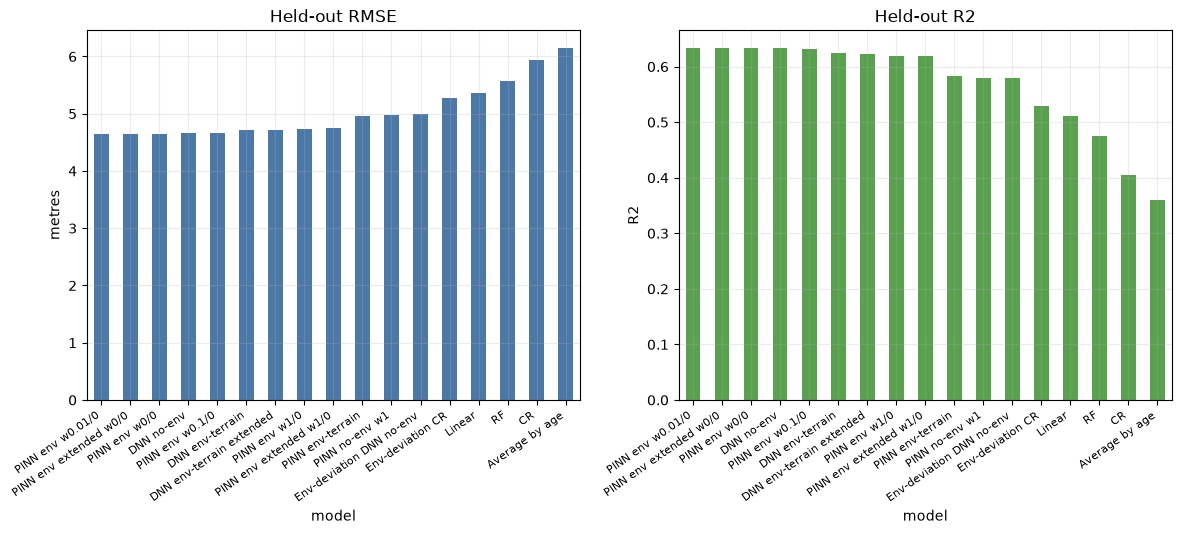

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
metrics["rmse"].sort_values().plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_title("Held-out RMSE")
axes[0].set_ylabel("metres")
metrics["r2"].sort_values(ascending=False).plot.bar(ax=axes[1], color="#59a14f")
axes[1].set_title("Held-out R2")
axes[1].set_ylabel("R2")
for ax in axes:
    ax.tick_params(axis="x", rotation=35, labelsize=8)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")


## Extra Experiment And Seed-Sensitivity Summary

This section includes newer output folders if they exist. It separates two questions:

1. Which individual run has the best held-out metrics?
2. Is an apparent improvement stable across split seeds, or is it dependent on which compartments happened to be held out?

In [6]:
extra_metrics = metrics.copy()
extra_metrics["model_group"] = predictions.groupby("model")["model_group"].first()
extra_metrics.sort_values("rmse")

,n_rows,n_plots,mae,rmse,r2,bias,residual_sd,model_group
model,,,,,,,,
PINN env w0.01/0,46956.0,11739.0,3.500353,4.651851,0.633538,0.377834,4.636531,extra
PINN env extended w0/0,46956.0,11739.0,3.500591,4.653184,0.633328,0.383301,4.637419,extra
PINN env w0/0,46956.0,11739.0,3.500591,4.653184,0.633328,0.383301,4.637419,extra
DNN no-env,46972.0,11743.0,3.497814,4.655366,0.633024,0.397426,4.638421,core
PINN env w0.1/0,46956.0,11739.0,3.517131,4.659731,0.632296,0.399063,4.642661,extra
DNN env-terrain,46956.0,11739.0,3.506825,4.707503,0.624718,-0.285271,4.698902,core
DNN env-terrain extended,46956.0,11739.0,3.563465,4.721200,0.622531,0.367269,4.706943,extra
PINN env w1/0,46956.0,11739.0,3.621723,4.740283,0.619473,0.342969,4.727910,extra
PINN env extended w1/0,46956.0,11739.0,3.623824,4.743256,0.618996,0.333075,4.731598,extra


In [7]:
import json
import re

def load_metrics_json(model_dir, cohort=COHORT, split_type=SPLIT_TYPE):
    path = ROOT / "outputs" / split_type / model_dir / cohort / "metrics.json"
    if not path.exists():
        return None
    with open(path) as f:
        row = json.load(f)
    row["model_dir"] = model_dir
    return row

def paired_seed_summary(model_prefix_noenv, model_prefix_env, base_noenv, base_env, seeds=range(42, 50)):
    rows = []
    for seed in seeds:
        noenv_dir = base_noenv if seed == 42 else f"{model_prefix_noenv}{seed}"
        env_dir = base_env if seed == 42 else f"{model_prefix_env}{seed}"
        noenv = load_metrics_json(noenv_dir)
        env = load_metrics_json(env_dir)
        if noenv is None or env is None:
            continue
        rows.append({
            "seed": seed,
            "noenv_dir": noenv_dir,
            "env_dir": env_dir,
            "noenv_rmse": noenv["rmse"],
            "env_rmse": env["rmse"],
            "delta_rmse_env_minus_noenv": env["rmse"] - noenv["rmse"],
            "noenv_r2": noenv["r2"],
            "env_r2": env["r2"],
            "delta_r2_env_minus_noenv": env["r2"] - noenv["r2"],
        })
    return pd.DataFrame(rows)

dnn_seed_pairs = paired_seed_summary(
    model_prefix_noenv="dnn_noenv_splitseed",
    model_prefix_env="dnn_env_terrain_splitseed",
    base_noenv="dnn_noenv",
    base_env="dnn_env_terrain",
)
pinn_seed_pairs = paired_seed_summary(
    model_prefix_noenv="pinn_noenv_splitseed",
    model_prefix_env="pinn_env_terrain_splitseed",
    base_noenv="pinn_noenv_basecase_w1",
    base_env="pinn_env_terrain",
)

seed_delta_summary = []
for label, df in [("DNN env - no-env", dnn_seed_pairs), ("PINN env - no-env", pinn_seed_pairs)]:
    if len(df):
        seed_delta_summary.append({
            "comparison": label,
            "n_seed_pairs": len(df),
            "mean_delta_r2": df["delta_r2_env_minus_noenv"].mean(),
            "sd_delta_r2": df["delta_r2_env_minus_noenv"].std(ddof=1) if len(df) > 1 else np.nan,
            "mean_delta_rmse": df["delta_rmse_env_minus_noenv"].mean(),
            "sd_delta_rmse": df["delta_rmse_env_minus_noenv"].std(ddof=1) if len(df) > 1 else np.nan,
        })
seed_delta_summary = pd.DataFrame(seed_delta_summary)

print("DNN paired split seeds")
display(dnn_seed_pairs.round(4))
print("PINN paired split seeds")
display(pinn_seed_pairs.round(4))
print("Summary")
seed_delta_summary.round(4)

DNN paired split seeds


,seed,noenv_dir,env_dir,noenv_rmse,env_rmse,delta_rmse_env_minus_noenv,noenv_r2,env_r2,delta_r2_env_minus_noenv
0,42,dnn_noenv,dnn_env_terrain,4.6554,4.7075,0.0521,0.6330,0.6247,-0.0083
1,43,dnn_noenv_splitseed43,dnn_env_terrain_splitseed43,4.6014,4.0713,-0.5301,0.6415,0.7193,0.0778
2,44,dnn_noenv_splitseed44,dnn_env_terrain_splitseed44,4.5936,4.3930,-0.2005,0.6427,0.6732,0.0305
3,45,dnn_noenv_splitseed45,dnn_env_terrain_splitseed45,4.5743,4.2109,-0.3634,0.6457,0.6997,0.0540
4,46,dnn_noenv_splitseed46,dnn_env_terrain_splitseed46,4.5995,4.5180,-0.0816,0.6418,0.6543,0.0126
5,47,dnn_noenv_splitseed47,dnn_env_terrain_splitseed47,4.6077,4.3249,-0.2828,0.6405,0.6832,0.0427
6,48,dnn_noenv_splitseed48,dnn_env_terrain_splitseed48,4.6186,4.1990,-0.4196,0.6388,0.7014,0.0626
7,49,dnn_noenv_splitseed49,dnn_env_terrain_splitseed49,4.5614,4.1419,-0.4195,0.6477,0.7095,0.0618


PINN paired split seeds


,seed,noenv_dir,env_dir,noenv_rmse,env_rmse,delta_rmse_env_minus_noenv,noenv_r2,env_r2,delta_r2_env_minus_noenv
0,42,pinn_noenv_basecase_w1,pinn_env_terrain,4.9815,4.9666,-0.0149,0.5798,0.5823,0.0025
1,43,pinn_noenv_splitseed43,pinn_env_terrain_splitseed43,5.6323,5.6584,0.0262,0.5036,0.4991,-0.0045
2,44,pinn_noenv_splitseed44,pinn_env_terrain_splitseed44,4.7816,4.7660,-0.0156,0.5650,0.5678,0.0028
3,45,pinn_noenv_splitseed45,pinn_env_terrain_splitseed45,5.2793,5.2692,-0.0101,0.5530,0.5547,0.0017
4,46,pinn_noenv_splitseed46,pinn_env_terrain_splitseed46,5.3560,5.3524,-0.0037,0.4676,0.4682,0.0006
5,47,pinn_noenv_splitseed47,pinn_env_terrain_splitseed47,5.6326,5.6028,-0.0297,0.5117,0.5169,0.0051
6,48,pinn_noenv_splitseed48,pinn_env_terrain_splitseed48,5.4402,5.4093,-0.0309,0.5955,0.6001,0.0045
7,49,pinn_noenv_splitseed49,pinn_env_terrain_splitseed49,4.9557,4.9713,0.0156,0.5955,0.5930,-0.0025


Summary


,comparison,n_seed_pairs,mean_delta_r2,sd_delta_r2,mean_delta_rmse,sd_delta_rmse
0,DNN env - no-env,8,0.0417,0.0287,-0.2807,0.1944
1,PINN env - no-env,8,0.0013,0.0033,-0.0079,0.0202


Interpretation guide:

- `delta_r2_env_minus_noenv > 0` means the environmental version performed better for that split seed.
- `delta_rmse_env_minus_noenv < 0` means the environmental version had lower error for that split seed.
- Compare DNN and PINN separately. The DNN and PINN do not use environmental features in the same way, so their seed behaviour answers different questions.

## Residual Distributions

If a model absorbs the structure left by Chapman-Richards, its residuals should be narrower and less biased. Positive residual means observed height is higher than predicted height, so the model is under-predicting.

Text(0.5, 0.98, '')

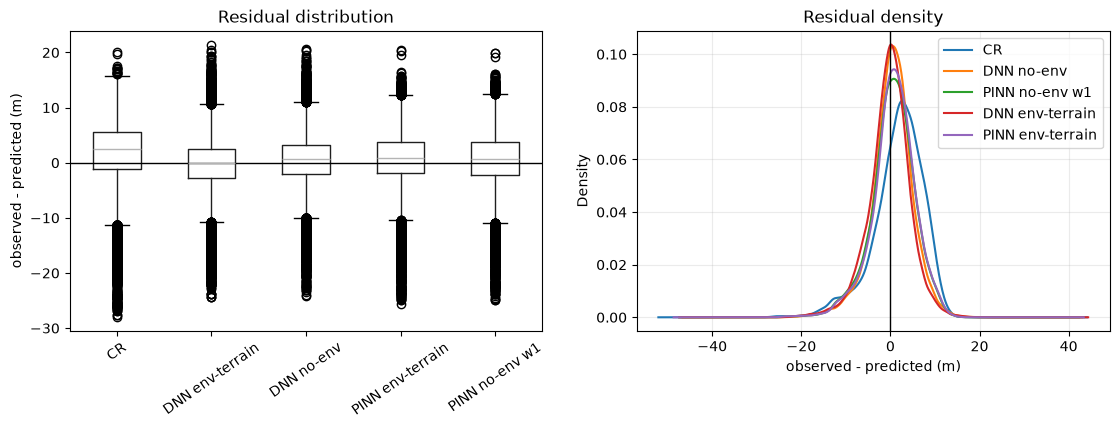

In [8]:
plot_df = predictions[predictions["model"].isin(CORE_MODELS)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_df.boxplot(column="residual", by="model", ax=axes[0], grid=False, rot=35)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residual distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("observed - predicted (m)")

for model, group in plot_df.groupby("model", sort=False):
    group["residual"].plot.kde(ax=axes[1], label=model)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Residual density")
axes[1].set_xlabel("observed - predicted (m)")
axes[1].legend()
plt.suptitle("")


## Age And Year Structure

These plots test whether the leftover errors are concentrated in particular stand ages or survey years. That matters because a model can have a decent RMSE while still missing a biologically important growth-stage pattern.

In [9]:
age_bins = [-np.inf, 30, 40, 60, 80, np.inf]
age_labels = ["<30", "30-40", "40-60", "60-80", "80+"]
plot_df["age_band"] = pd.cut(plot_df["Age"], bins=age_bins, labels=age_labels)

age_summary = (
    plot_df.groupby(["model", "age_band"], observed=True)
    .agg(n=("residual", "size"), bias=("residual", "mean"), mae=("residual", lambda x: np.mean(np.abs(x))), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)
age_summary

,model,age_band,n,bias,mae,rmse
0,CR,<30,13720,0.732355,2.654058,3.309300
1,CR,30-40,15861,2.883190,5.014244,5.853330
2,CR,40-60,11692,2.204597,6.249953,7.365824
3,CR,60-80,4433,0.839228,5.807031,7.324198
4,CR,80+,1266,-2.269281,6.042944,8.231172
5,DNN env-terrain,<30,13720,-0.329515,2.506693,3.225253
6,DNN env-terrain,30-40,15861,-0.656693,3.114328,4.042570
7,DNN env-terrain,40-60,11684,-0.385743,4.092990,5.366724
8,DNN env-terrain,60-80,4428,1.517158,5.856177,7.264909
9,DNN env-terrain,80+,1263,-0.529994,5.641062,7.360357


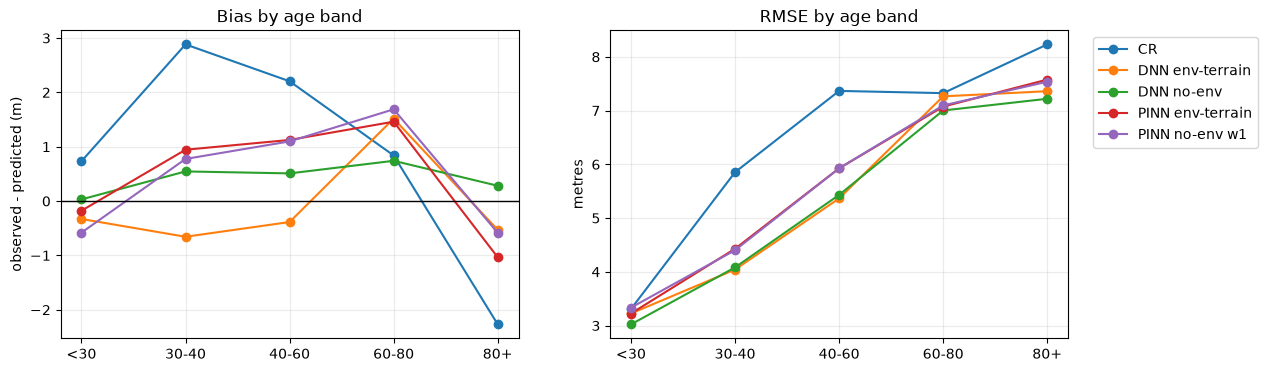

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, group in age_summary.groupby("model", sort=False):
    axes[0].plot(group["age_band"].astype(str), group["bias"], marker="o", label=model)
    axes[1].plot(group["age_band"].astype(str), group["rmse"], marker="o", label=model)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Bias by age band")
axes[0].set_ylabel("observed - predicted (m)")
axes[1].set_title("RMSE by age band")
axes[1].set_ylabel("metres")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")


,model,LiDAR_year,n,bias,rmse
0,CR,2008,11743,0.127322,4.451459
1,CR,2012,11743,1.030126,5.193275
2,CR,2021,11743,2.521774,6.507516
3,CR,2023,11743,3.337871,7.177236
4,DNN env-terrain,2008,11739,-0.436713,3.950468
5,DNN env-terrain,2012,11739,-0.470629,4.555760
6,DNN env-terrain,2021,11739,-0.464096,4.973041
7,DNN env-terrain,2023,11739,0.230354,5.248816
8,DNN no-env,2008,11743,0.093467,3.786650
9,DNN no-env,2012,11743,0.118086,4.340963


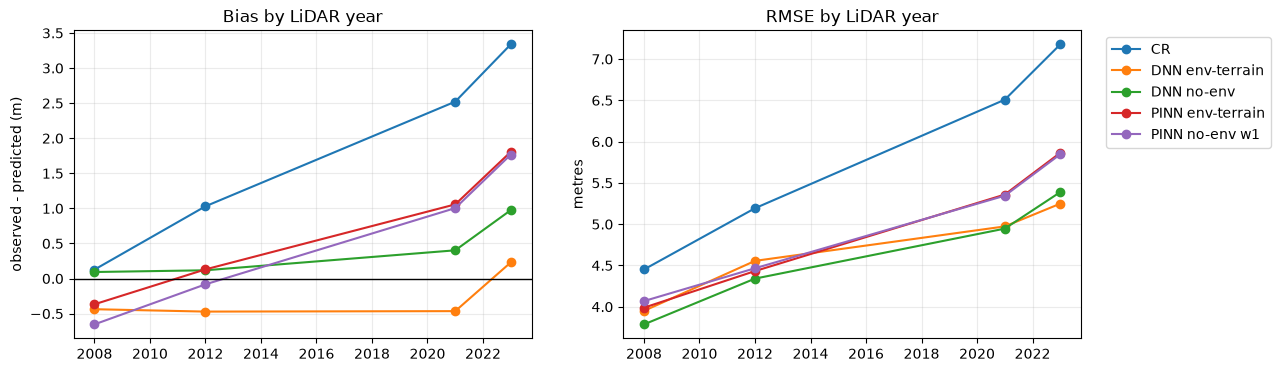

In [11]:
year_summary = (
    plot_df.groupby(["model", "LiDAR_year"])
    .agg(n=("residual", "size"), bias=("residual", "mean"), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model, group in year_summary.groupby("model", sort=False):
    axes[0].plot(group["LiDAR_year"], group["bias"], marker="o", label=model)
    axes[1].plot(group["LiDAR_year"], group["rmse"], marker="o", label=model)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Bias by LiDAR year")
axes[0].set_ylabel("observed - predicted (m)")
axes[1].set_title("RMSE by LiDAR year")
axes[1].set_ylabel("metres")
axes[1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")

year_summary

## Compartment-Level Bias

Spatial block testing holds out whole areas, so compartment-level residual means are a useful way to see whether a model is still systematically too high/low in particular forest compartments.

In [12]:
cpmt_summary = (
    plot_df.groupby(["model", "cpmt"])
    .agg(n=("residual", "size"), bias=("residual", "mean"), rmse=("residual", lambda x: np.sqrt(np.mean(x ** 2))))
    .reset_index()
)

cpmt_spread = (
    cpmt_summary.groupby("model")
    .agg(n_compartments=("cpmt", "nunique"), mean_abs_cpmt_bias=("bias", lambda x: np.mean(np.abs(x))), max_abs_cpmt_bias=("bias", lambda x: np.max(np.abs(x))))
    .sort_values("mean_abs_cpmt_bias")
)
cpmt_spread

,n_compartments,mean_abs_cpmt_bias,max_abs_cpmt_bias
model,,,
DNN env-terrain,51,2.894074,10.490663
DNN no-env,51,2.932937,7.979750
PINN no-env w1,51,3.386965,10.638840
PINN env-terrain,51,3.426343,10.737503
CR,51,4.296497,15.833689


model,CR,DNN env-terrain,DNN no-env,PINN env-terrain,PINN no-env w1
cpmt,,,,,
2069,-15.833689,-9.183439,-7.797420,-10.737503,-10.638840
1105,-13.481729,-8.473110,-6.253606,-10.690064,-10.527917
2070,-12.862190,-8.184799,-7.001232,-8.669977,-8.644001
2094,-11.230138,-4.057524,-7.979750,-9.125177,-9.364391
1120,-8.686160,-7.062871,-7.278663,-7.838969,-7.617509
2056,-8.578102,-2.709912,-0.260738,-2.848399,-3.040606
2111,-8.015064,-3.313427,-5.375073,-5.376874,-5.422647
1095,7.769518,3.445545,2.985880,3.265348,3.183164
2185,6.027293,0.797796,1.349065,1.630225,1.582608


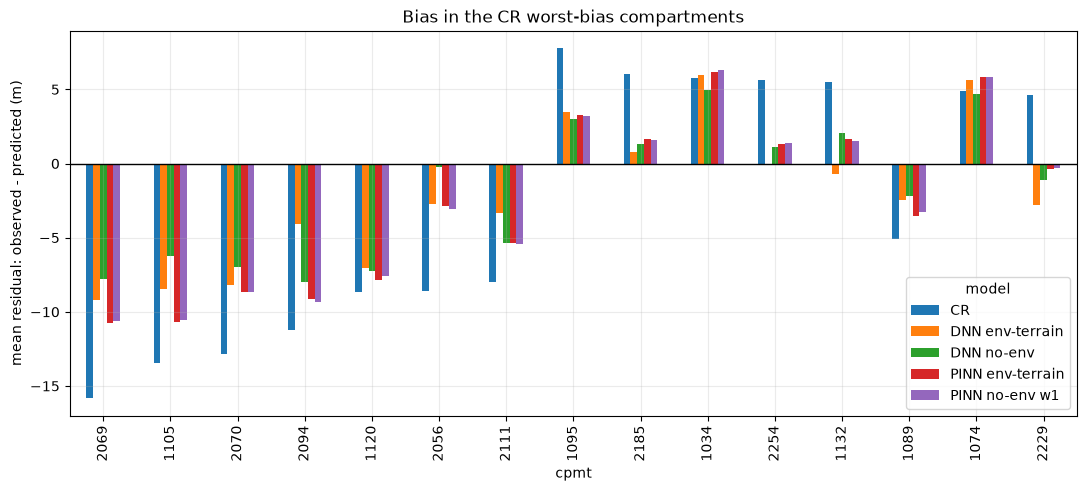

In [13]:
reference_model = "CR"
top_compartments = (
    cpmt_summary[cpmt_summary["model"] == reference_model]
    .assign(abs_bias=lambda d: d["bias"].abs())
    .sort_values("abs_bias", ascending=False)
    .head(15)["cpmt"]
)

top_cpmt = cpmt_summary[cpmt_summary["cpmt"].isin(top_compartments)].copy()
pivot = top_cpmt.pivot(index="cpmt", columns="model", values="bias").loc[top_compartments]
pivot.plot.bar(figsize=(13, 5))
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Bias in the {reference_model} worst-bias compartments")
plt.ylabel("mean residual: observed - predicted (m)")

pivot

## Worst-Error Concentration

This section tests whether the largest errors are diffuse random noise or concentrated in specific ages, years, compartments, and repeat-offender plots.

The default focus model is `DNN no-env`, because it is the strongest core single-run model in the primary `4survey spatial_block` comparison. Change `FOCUS_MODEL` to repeat the same check for another model.

In [14]:
FOCUS_MODEL = "DNN no-env"
N_WORST = 100

focus_df = predictions[predictions["model"] == FOCUS_MODEL].copy()
focus_df["abs_error"] = focus_df["residual"].abs()
focus_df["age_band"] = pd.cut(focus_df["Age"], bins=age_bins, labels=age_labels)
worst_df = focus_df.nlargest(N_WORST, "abs_error").copy()

worst_overview = pd.Series({
    "focus_model": FOCUS_MODEL,
    "n_rows_population": len(focus_df),
    "n_plots_population": focus_df["identification"].nunique(),
    "n_compartments_population": focus_df["cpmt"].nunique(),
    "n_worst_rows": len(worst_df),
    "n_worst_plots": worst_df["identification"].nunique(),
    "n_worst_compartments": worst_df["cpmt"].nunique(),
    "worst_mean_age": worst_df["Age"].mean(),
    "population_mean_age": focus_df["Age"].mean(),
    "worst_min_observed_height": worst_df["observed_top_height"].min(),
    "worst_max_observed_height": worst_df["observed_top_height"].max(),
    "repeat_offender_rows": worst_df.duplicated("identification", keep=False).sum(),
    "repeat_offender_plots": (worst_df["identification"].value_counts() > 1).sum(),
    "max_rows_for_one_plot": worst_df["identification"].value_counts().max(),
})
worst_overview

focus_model                  DNN no-env
n_rows_population                 46972
n_plots_population                11743
n_compartments_population            51
n_worst_rows                        100
n_worst_plots                        63
n_worst_compartments                 18
worst_mean_age                    70.75
population_mean_age           40.202759
worst_min_observed_height      2.374841
worst_max_observed_height     41.278942
repeat_offender_rows                 69
repeat_offender_plots                32
max_rows_for_one_plot                 4
dtype: object

In [15]:
def share_table(series_worst, series_population, label):
    out = pd.DataFrame({
        f"worst_{N_WORST}_pct": series_worst,
        "population_pct": series_population,
    }).fillna(0)
    out["enrichment_ratio"] = out[f"worst_{N_WORST}_pct"] / out["population_pct"].replace(0, np.nan)
    out.index.name = label
    return out

age_concentration = share_table(
    worst_df["age_band"].value_counts(normalize=True, sort=False) * 100,
    focus_df["age_band"].value_counts(normalize=True, sort=False) * 100,
    "age_band",
)
year_concentration = share_table(
    worst_df["LiDAR_year"].value_counts(normalize=True).sort_index() * 100,
    focus_df["LiDAR_year"].value_counts(normalize=True).sort_index() * 100,
    "LiDAR_year",
)

print("Age concentration")
display(age_concentration.round(2))
print("Year concentration")
display(year_concentration.round(2))

Age concentration


,worst_100_pct,population_pct,enrichment_ratio
age_band,,,
<30,2.0,29.21,0.07
30-40,1.0,33.77,0.03
40-60,19.0,24.89,0.76
60-80,45.0,9.44,4.77
80+,33.0,2.70,12.24


Year concentration


,worst_100_pct,population_pct,enrichment_ratio
LiDAR_year,,,
2008,12.0,25.0,0.48
2012,14.0,25.0,0.56
2021,28.0,25.0,1.12
2023,46.0,25.0,1.84


In [16]:
top_worst_compartments = worst_df["cpmt"].value_counts().rename_axis("cpmt").reset_index(name="worst_rows")
top_worst_compartments["worst_pct"] = 100 * top_worst_compartments["worst_rows"] / len(worst_df)
compartment_population_rows = focus_df["cpmt"].value_counts().rename_axis("cpmt").reset_index(name="population_rows")
top_worst_compartments = top_worst_compartments.merge(compartment_population_rows, on="cpmt", how="left")
top_worst_compartments["population_pct"] = 100 * top_worst_compartments["population_rows"] / len(focus_df)
top_worst_compartments["enrichment_ratio"] = top_worst_compartments["worst_pct"] / top_worst_compartments["population_pct"]

top_repeat_plots = (
    worst_df.groupby("identification")
    .agg(
        worst_rows=("abs_error", "size"),
        max_abs_error=("abs_error", "max"),
        cpmt=("cpmt", "first"),
        years=("LiDAR_year", lambda x: tuple(sorted(x))),
        age_min=("Age", "min"),
        age_max=("Age", "max"),
        observed_min=("observed_top_height", "min"),
        observed_max=("observed_top_height", "max"),
    )
    .query("worst_rows > 1")
    .sort_values(["worst_rows", "max_abs_error"], ascending=[False, False])
)

print("Top compartments among the worst errors")
display(top_worst_compartments.head(15).round(2))
print("Repeat-offender plots in the worst errors")
display(top_repeat_plots.head(20).round(2))

Top compartments among the worst errors


,cpmt,worst_rows,worst_pct,population_rows,population_pct,enrichment_ratio
0,1089,26,26.0,540,1.15,22.62
1,1085,18,18.0,1664,3.54,5.08
2,2070,16,16.0,136,0.29,55.26
3,1119,8,8.0,1248,2.66,3.01
4,2194,8,8.0,1568,3.34,2.40
5,2111,4,4.0,392,0.83,4.79
6,1095,3,3.0,504,1.07,2.80
7,2222,2,2.0,212,0.45,4.43
8,2196,2,2.0,704,1.50,1.33
9,2254,2,2.0,2176,4.63,0.43


Repeat-offender plots in the worst errors


,worst_rows,max_abs_error,cpmt,years,age_min,age_max,observed_min,observed_max
identification,,,,,,,,
309114,4,21.52,1089,"(2008, 2012, 2021, 2023)",74,89,3.58,8.85
262683,3,24.22,1085,"(2008, 2012, 2021)",74,87,5.46,13.62
309100,3,22.03,1089,"(2008, 2012, 2021)",74,87,4.57,14.10
216259,3,20.00,2194,"(2012, 2021, 2023)",59,70,3.80,11.16
309103,2,23.91,1089,"(2021, 2023)",87,89,7.65,9.26
262682,2,23.50,1085,"(2008, 2012)",74,78,7.92,10.20
239814,2,23.06,1085,"(2021, 2023)",87,89,7.27,8.68
239855,2,22.69,1085,"(2021, 2023)",87,89,6.72,8.73
232764,2,22.67,1119,"(2008, 2012)",69,73,7.91,10.53


In [17]:
# Compare worst-error terrain/site values with the whole test population.
env_for_worst = pd.read_parquet(ROOT / "data" / "processed" / "environmental" / "plot_environmental_features.parquet")
env_for_worst = env_for_worst.drop_duplicates("identification")

terrain_check_cols = [
    "ceh_twi", "elevation", "topex", "northness", "eastness", "whcl",
    "slope_degrees", "plan_curvature", "dist_to_watercourse", "dist_to_road",
]
terrain_check_cols = [c for c in terrain_check_cols if c in env_for_worst.columns]

focus_with_env = focus_df.merge(env_for_worst[["identification", *terrain_check_cols]], on="identification", how="left")
worst_with_env = worst_df.merge(env_for_worst[["identification", *terrain_check_cols]], on="identification", how="left")

terrain_rows = []
for col in terrain_check_cols:
    pop_values = focus_with_env[col].dropna()
    worst_values = worst_with_env[col].dropna()
    if len(worst_values) == 0 or len(pop_values) == 0:
        continue
    terrain_rows.append({
        "variable": col,
        "worst_median": worst_values.median(),
        "population_median": pop_values.median(),
        "worst_p10": worst_values.quantile(0.10),
        "worst_p90": worst_values.quantile(0.90),
        "population_p10": pop_values.quantile(0.10),
        "population_p90": pop_values.quantile(0.90),
    })
terrain_worst_summary = pd.DataFrame(terrain_rows)
terrain_worst_summary.round(3)

,variable,worst_median,population_median,worst_p10,worst_p90,population_p10,population_p90
0,ceh_twi,6.723,7.268,6.013,8.601,6.217,9.441
1,elevation,131.850,125.500,108.820,156.860,58.400,335.200
2,topex,1.634,1.609,-10.968,10.804,-32.906,16.204
3,northness,0.784,-0.198,-0.334,0.996,-0.968,0.983
4,eastness,-0.127,0.127,-0.782,0.933,-0.745,0.939
5,whcl,4.000,4.000,3.000,4.000,2.000,4.000
6,slope_degrees,9.160,7.459,3.223,15.838,2.500,19.519
7,plan_curvature,0.003,0.001,-0.007,0.008,-0.008,0.011
8,dist_to_watercourse,272.791,452.457,98.682,667.681,113.512,856.800
9,dist_to_road,93.373,125.465,21.282,161.690,25.011,650.175


In [18]:
# Repeat the concentration check for all core models, so we do not overgeneralise from one model.
concentration_rows = []
for model in CORE_MODELS:
    sub = predictions[predictions["model"] == model].copy()
    if sub.empty:
        continue
    sub["abs_error"] = sub["residual"].abs()
    sub["age_band"] = pd.cut(sub["Age"], bins=age_bins, labels=age_labels)
    worst = sub.nlargest(N_WORST, "abs_error")
    older_worst_share = worst["age_band"].isin(["60-80", "80+"]).mean()
    recent_worst_share = worst["LiDAR_year"].isin([2021, 2023]).mean()
    top3_cpmt_rows = worst["cpmt"].value_counts().head(3).sum()
    concentration_rows.append({
        "model": model,
        "worst_mean_age": worst["Age"].mean(),
        "population_mean_age": sub["Age"].mean(),
        "worst_60plus_pct": 100 * older_worst_share,
        "population_60plus_pct": 100 * sub["age_band"].isin(["60-80", "80+"]).mean(),
        "worst_2021_2023_pct": 100 * recent_worst_share,
        "population_2021_2023_pct": 100 * sub["LiDAR_year"].isin([2021, 2023]).mean(),
        "worst_compartments": worst["cpmt"].nunique(),
        "population_compartments": sub["cpmt"].nunique(),
        "top3_compartment_worst_rows": top3_cpmt_rows,
        "repeat_offender_plots": int((worst["identification"].value_counts() > 1).sum()),
    })
concentration_summary = pd.DataFrame(concentration_rows)
concentration_summary.round(2)

,model,worst_mean_age,population_mean_age,worst_60plus_pct,population_60plus_pct,worst_2021_2023_pct,population_2021_2023_pct,worst_compartments,population_compartments,top3_compartment_worst_rows,repeat_offender_plots
0,CR,79.34,40.20,93.0,12.13,58.0,50.0,13,51,83,27
1,DNN no-env,70.75,40.20,78.0,12.13,74.0,50.0,18,51,60,32
2,PINN no-env w1,75.16,40.20,78.0,12.13,60.0,50.0,12,51,80,25
3,DNN env-terrain,70.78,40.19,65.0,12.12,53.0,50.0,11,51,79,32
4,PINN env-terrain,75.66,40.19,80.0,12.12,59.0,50.0,11,51,83,25


Interpretation guide:

- If the worst errors are concentrated in older stands, recent years, a few compartments, and repeated plots, that is evidence against a purely diffuse random-noise explanation.
- It is not proof of data corruption. Plausible observed heights mean the extreme rows are not obviously impossible measurements.
- It is also not proof that terrain is the dominant missing driver. If the terrain summaries are not extreme, the worst cases may reflect compartment history, local disturbance, species/stand definition issues, edge effects, or unmeasured site variables.

## Join Residuals To Coordinates And Environmental Variables

For spatial and environmental diagnostics, use one row per plot per model: the mean held-out residual across that plot's test years. This avoids treating repeated survey years from the same plot as independent spatial samples.

In [19]:
plot_residuals = (
    plot_df.groupby(["model", "identification", "cpmt"], as_index=False)
    .agg(
        mean_residual=("residual", "mean"),
        mean_abs_residual=("residual", lambda x: np.mean(np.abs(x))),
        n_years=("LiDAR_year", "nunique"),
        mean_age=("Age", "mean"),
        mean_observed_height=("observed_top_height", "mean"),
    )
)

env_path = ROOT / "data" / "processed" / "environmental" / "plot_environmental_features.parquet"
coords_path = ROOT / "data" / "interim" / "plot_coordinates.csv.gz"
env = pd.read_parquet(env_path)
coords = pd.read_csv(coords_path)

join_cols = ["identification", "cpmt"]
env_unique = env.drop_duplicates("identification")
coords_unique = coords.drop_duplicates("identification")

residual_env = plot_residuals.merge(coords_unique, on=join_cols, how="left", suffixes=("", "_coord"))
env_extra_cols = [c for c in env_unique.columns if c not in residual_env.columns or c in ["identification", "cpmt"]]
residual_env = residual_env.merge(env_unique[env_extra_cols], on=join_cols, how="left")

print(residual_env.shape)
residual_env.head()

(58707, 69)


,model,identification,cpmt,mean_residual,mean_abs_residual,n_years,mean_age,mean_observed_height,x,y,mean_cr_residual_4survey,mean_cr_residual_6survey,groundfrost_mean_4survey,groundfrost_mean_6survey,rainfall_mean_4survey,rainfall_mean_6survey,sfcWind_mean_4survey,sfcWind_mean_6survey,sun_mean_4survey,sun_mean_6survey,tas_mean_4survey,tas_mean_6survey,tasmax_mean_4survey,tasmax_mean_6survey,tasmin_mean_4survey,tasmin_mean_6survey,era5_land_temp_k,ceh_pedotope,ceh_twi,ceh_subsurface_drainage,ceh_textural_composition,soilgrids_ph,chelsa_bio1_celsius,chelsa_gdd5_degc,chelsa_bio12_precip_mm,gwa_wind_speed_10m,dist_to_cpmt_boundary,dist_to_forest_perimeter,scpt,blk,dist_to_scpt_boundary,dist_to_block_boundary,cpmt_compactness_ratio,elevation_roughness,neighbour_mean_height,neighbour_height_differential,slope_degrees,aspect_degrees,profile_curvature,plan_curvature,tpi,frost_hollow_flag,solar_radiation_index,inverse_slope_proxy,dist_to_watercourse,dist_to_road,topex,elevation,windward_topex,northness,eastness,whcl,Age,CanopyCover,Thin,time_since_thinning,time_since_thinning_missing,recent_thinning_5yr,yldc
0,CR,14684,2056,-8.575808,8.575808,4,34.0,9.167174,242115.406,704028.4975,-8.817584,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,10.0,7.021230,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,49.241834,49.241834,A,31,62.019586,38.737590,0.021488,31.932692,7.336059,2.228140,23.223392,80.340107,-0.000429,-0.001647,-3.200,0.0,0.737485,-23.223392,571.564773,411.222003,-8.715328,244.0,2.159028,0.167799,0.985821,4,34.0,0.195229,0.0,0.0,1.0,0.0,12
1,CR,14687,2056,-11.621195,11.621195,4,34.0,6.121788,242175.406,704028.4975,-11.862971,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,11.0,7.416276,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,31.622777,99.146662,A,31,44.606813,31.622777,0.021488,26.761583,12.087545,-5.699401,21.164226,65.752011,-0.000716,-0.003272,-6.336,1.0,0.704536,-21.164226,518.204691,362.099234,-0.343905,224.1,3.861607,0.410687,0.911776,4,34.0,0.107041,0.0,0.0,1.0,0.0,12
2,CR,14693,2056,-11.766196,11.766196,4,34.0,5.976786,242175.406,704048.4975,-12.007972,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,11.0,7.416276,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,14.142136,110.249756,A,31,37.454110,14.142136,0.021488,26.761583,14.471503,-7.270119,21.164226,65.752011,-0.000716,-0.003272,-6.336,1.0,0.704536,-21.164226,508.998980,350.231003,-0.343905,224.1,3.861607,0.410687,0.911776,4,34.0,0.129532,0.0,0.0,1.0,0.0,12
3,CR,14699,2056,-11.778214,11.778214,4,34.0,5.964768,242155.406,704068.4975,-12.019990,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,11.0,7.156669,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,30.000000,104.717906,A,31,37.607196,30.000000,0.021488,29.762318,10.219762,-2.668800,25.235761,65.827683,-0.000885,-0.001898,-6.304,1.0,0.666772,-25.235761,517.813026,356.188455,4.987611,215.0,5.778659,0.409482,0.912318,4,34.0,0.147598,0.0,0.0,1.0,0.0,12
4,CR,14710,2056,-4.981556,4.981556,4,34.0,12.761426,242115.406,704108.4975,-5.223332,NaN,8.927716,8.775445,186.691537,197.347164,3.452893,3.523292,101.385696,99.210691,8.988315,9.074582,12.695123,12.755081,5.253881,5.376972,272.766499,10.0,5.679075,1.0,4.0,4.4,8.05,1296.0,2424.9,1.541,37.876671,93.654208,A,31,37.913366,37.876671,0.021488,35.632135,9.868493,2.954358,29.083267,73.389556,0.001272,0.003405,8.988,0.0,0.660238,-29.083267,535.441119,368.533274,-1.527459,237.9,5.489268,0.285863,0.958270,4,34.0,0.396103,0.0,0.0,1.0,0.0,12


## Spatial Residual Maps

These maps are visual diagnostics only. Look for whether the same high/low residual zones visible in the Chapman-Richards map remain in the DNN/PINN maps.

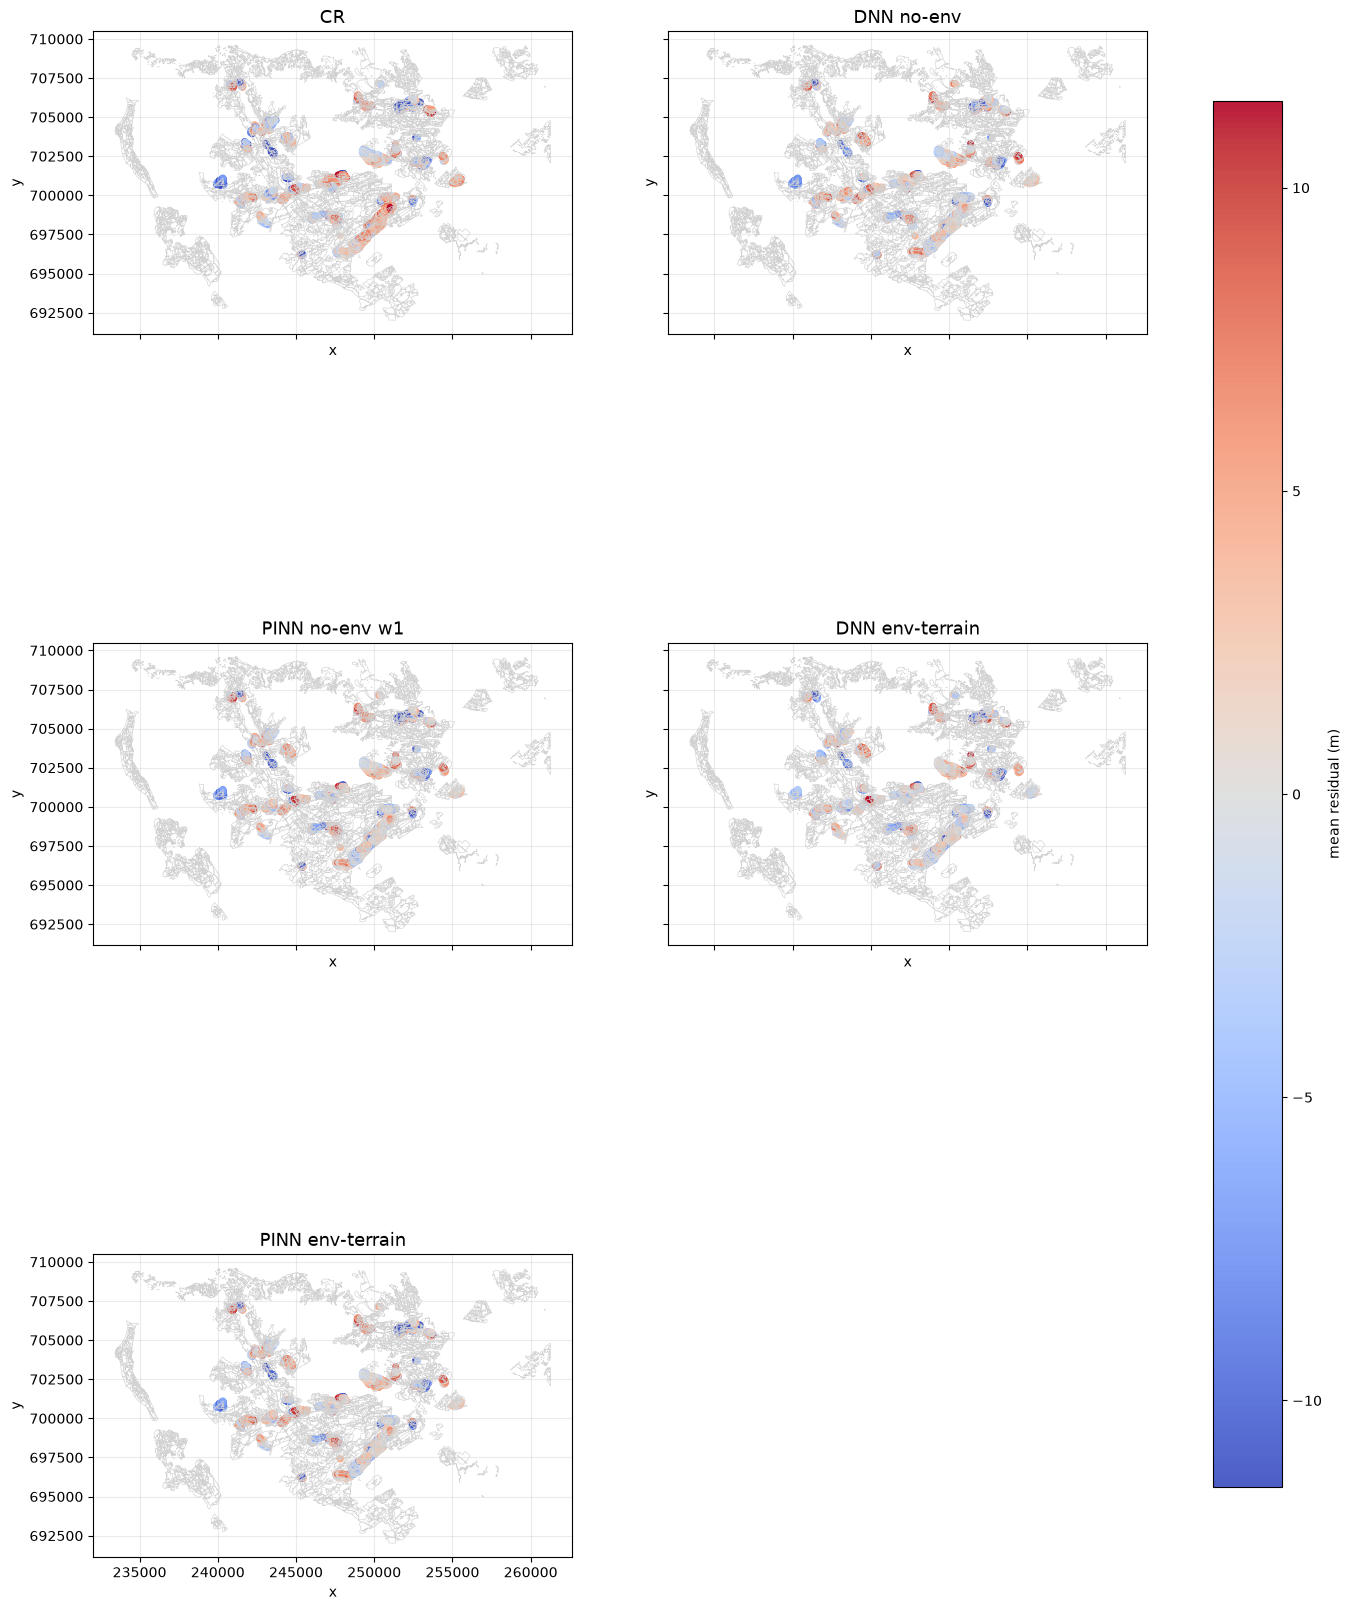

In [20]:
map_models = [m for m in CORE_MODELS if m in residual_env["model"].unique()]
vmax = np.nanpercentile(np.abs(residual_env[residual_env["model"].isin(map_models)]["mean_residual"]), 98)

def load_compartment_boundaries_optional():
    try:
        from models.common.geo import load_compartment_boundaries
        return load_compartment_boundaries()
    except Exception as exc:
        print(f"Compartment boundary overlay skipped: {type(exc).__name__}: {exc}")
        return None

def plot_compartment_background(ax, boundaries=None, cpmts=None, color="#d0d0d0", linewidth=0.35, alpha=0.9):
    if boundaries is None:
        return
    plot_boundaries = boundaries
    if cpmts is not None:
        plot_boundaries = plot_boundaries[plot_boundaries["cpmt"].isin(cpmts)]
    if len(plot_boundaries) == 0:
        return
    try:
        plot_boundaries.boundary.plot(ax=ax, color=color, linewidth=linewidth, alpha=alpha)
    except Exception as exc:
        print(f"Boundary overlay failed: {type(exc).__name__}: {exc}")

compartment_boundaries = load_compartment_boundaries_optional()

n_cols = min(2, len(map_models))
n_rows = int(np.ceil(len(map_models) / n_cols))
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8.5 * n_cols, 7.5 * n_rows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
axes_flat = axes.ravel()

for ax, model in zip(axes_flat, map_models):
    sub = residual_env[residual_env["model"] == model].dropna(subset=["x", "y"])
    plot_compartment_background(ax, compartment_boundaries, linewidth=0.45, alpha=0.95)
    sc = ax.scatter(
        sub["x"],
        sub["y"],
        c=sub["mean_residual"],
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        s=16,
        alpha=0.9,
    )
    ax.set_title(model, fontsize=13)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

for ax in axes_flat[len(map_models):]:
    ax.set_visible(False)

fig.colorbar(sc, ax=axes_flat[:len(map_models)], shrink=0.8, label="mean residual (m)")


## Worst-Error And Problem-Compartment Maps

These maps connect the tabular worst-error analysis to geography. They answer: are the worst errors scattered across the forest, or concentrated in a few places?

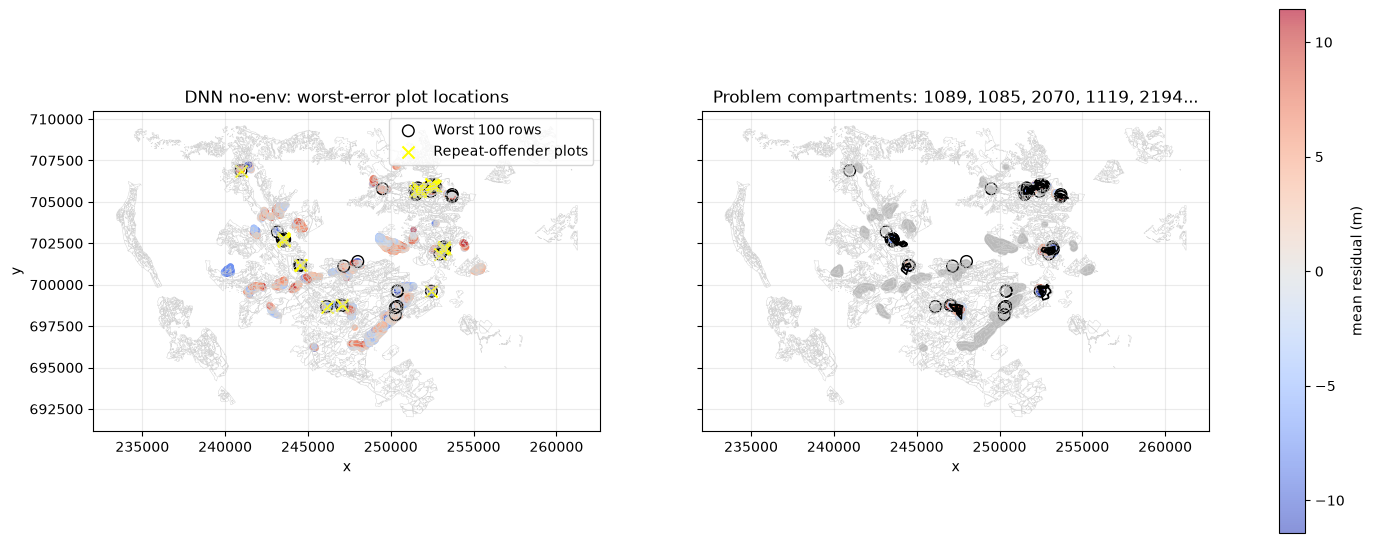

In [21]:
# Map the focus model's worst rows and the compartments most represented in those rows.
problem_cpmts = top_worst_compartments.head(8)["cpmt"].tolist()
problem_labels = ", ".join(str(c) for c in problem_cpmts[:5])

focus_plot_residuals = residual_env[residual_env["model"] == FOCUS_MODEL].copy()
worst_plot_ids = set(worst_df["identification"])
repeat_plot_ids = set(top_repeat_plots.index)

focus_plot_residuals["in_worst_rows"] = focus_plot_residuals["identification"].isin(worst_plot_ids)
focus_plot_residuals["repeat_offender"] = focus_plot_residuals["identification"].isin(repeat_plot_ids)
focus_plot_residuals["problem_cpmt"] = focus_plot_residuals["cpmt"].isin(problem_cpmts)

fig, axes = plt.subplots(1, 2, figsize=(18, 8.5), sharex=True, sharey=True)

# Left: all plot residuals, with the worst-error points overlaid.
plot_compartment_background(axes[0], compartment_boundaries)
base = focus_plot_residuals.dropna(subset=["x", "y"])
sc = axes[0].scatter(base["x"], base["y"], c=base["mean_residual"], cmap="coolwarm", vmin=-vmax, vmax=vmax, s=13, alpha=0.6)
worst_points = base[base["in_worst_rows"]]
repeat_points = base[base["repeat_offender"]]
axes[0].scatter(worst_points["x"], worst_points["y"], facecolors="none", edgecolors="black", s=70, linewidths=1.0, label=f"Worst {N_WORST} rows")
axes[0].scatter(repeat_points["x"], repeat_points["y"], marker="x", color="yellow", s=76, linewidths=1.5, label="Repeat-offender plots")
axes[0].set_title(f"{FOCUS_MODEL}: worst-error plot locations")
axes[0].legend(loc="best")

# Right: highlight problem compartments and all focus-model residuals inside/around them.
plot_compartment_background(axes[1], compartment_boundaries)
plot_compartment_background(axes[1], compartment_boundaries, cpmts=problem_cpmts, color="black", linewidth=1.2, alpha=1.0)
axes[1].scatter(base["x"], base["y"], color="#bbbbbb", s=9, alpha=0.25)
problem_points = base[base["problem_cpmt"]]
axes[1].scatter(problem_points["x"], problem_points["y"], c=problem_points["mean_residual"], cmap="coolwarm", vmin=-vmax, vmax=vmax, s=22, alpha=0.9)
axes[1].scatter(worst_points["x"], worst_points["y"], facecolors="none", edgecolors="black", s=70, linewidths=1.0)
axes[1].set_title(f"Problem compartments: {problem_labels}...")

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(sc, ax=axes, shrink=0.8, label="mean residual (m)")


## LISA Cluster Map

LISA, or Local Moran's I, identifies where residuals form statistically significant local clusters. This is stricter than simply mapping large errors: it asks whether a plot and its neighbours share unusually high or low residuals after correcting for many simultaneous local tests.

Labels:

- `High-High`: plot and neighbours have above-average residuals. The model tends to under-predict this local area.
- `Low-Low`: plot and neighbours have below-average residuals. The model tends to over-predict this local area.
- `High-Low` / `Low-High`: local spatial outliers.
- `Not significant`: no statistically clear local cluster for that plot.

Default uses `k=20` nearest neighbours and `199` permutations so the notebook remains usable. Increase to `999` for a final, slower version.

In [22]:
RUN_LISA = False
LISA_K = 20
LISA_PERMUTATIONS = 199

if RUN_LISA:
    try:
        from models.spatial_attribution.lisa import local_morans_i
        lisa_input = focus_plot_residuals.dropna(subset=["x", "y", "mean_residual"]).copy()
        labels, local_i, raw_p = local_morans_i(
            lisa_input["x"], lisa_input["y"], lisa_input["mean_residual"],
            k=LISA_K, permutations=LISA_PERMUTATIONS, seed=42,
        )
        lisa_input["lisa_label"] = labels
        lisa_input["local_morans_i"] = local_i
        lisa_input["raw_lisa_p"] = raw_p
        lisa_summary = lisa_input["lisa_label"].value_counts().rename_axis("lisa_label").reset_index(name="n_plots")
        lisa_summary["pct_plots"] = 100 * lisa_summary["n_plots"] / len(lisa_input)
        display(lisa_summary)
    except Exception as exc:
        lisa_input = pd.DataFrame()
        lisa_summary = pd.DataFrame({"message": [f"LISA skipped: {type(exc).__name__}: {exc}"]})
        display(lisa_summary)
else:
    lisa_input = pd.DataFrame()
    lisa_summary = pd.DataFrame({"message": ["LISA skipped because RUN_LISA=False"]})
    display(lisa_summary)

,message
0,LISA skipped because RUN_LISA=False


In [23]:
if len(lisa_input):
    lisa_colors = {
        "High-High": "#b2182b",
        "Low-Low": "#2166ac",
        "High-Low": "#ef8a62",
        "Low-High": "#67a9cf",
        "Not significant": "#d9d9d9",
    }
    lisa_order = ["High-High", "Low-Low", "High-Low", "Low-High", "Not significant"]

    fig, ax = plt.subplots(figsize=(13, 11))
    plot_compartment_background(ax, compartment_boundaries)
    for label in lisa_order:
        sub = lisa_input[lisa_input["lisa_label"] == label]
        if len(sub) == 0:
            continue
        ax.scatter(
            sub["x"], sub["y"],
            s=28 if label != "Not significant" else 10,
            color=lisa_colors[label],
            alpha=0.9 if label != "Not significant" else 0.25,
            label=f"{label} ({len(sub)})",
        )

    # Overlay repeated worst-error plots so you can see whether they sit inside significant clusters.
    if "repeat_offender" in focus_plot_residuals.columns:
        repeat_overlay = lisa_input[lisa_input["identification"].isin(repeat_plot_ids)]
        ax.scatter(repeat_overlay["x"], repeat_overlay["y"], marker="x", color="yellow", s=90, linewidths=1.6, label="Repeat-offender plots")

    plot_compartment_background(ax, compartment_boundaries, cpmts=problem_cpmts, color="black", linewidth=1.0, alpha=1.0)
    ax.set_title(f"{FOCUS_MODEL}: LISA residual clusters, k={LISA_K}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="best", fontsize=8)
else:
    print("No LISA map drawn because LISA did not run.")

No LISA map drawn because LISA did not run.


## Spatial Autocorrelation

This estimates the spatial range with a semivariogram and then calculates Moran's I at that distance. If the DNN/PINN has absorbed the spatial structure in the CR residuals, Moran's I should fall. If it stays high, important spatial structure remains unexplained.

This section is useful but slow, so it is opt-in by default. Set `RUN_GLOBAL_SPATIAL_AUTOCORR = True` in the next cell when you want the full test.

In [24]:
RUN_GLOBAL_SPATIAL_AUTOCORR = False

if RUN_GLOBAL_SPATIAL_AUTOCORR:
    try:
        from models.spatial_attribution.spatial_autocorrelation import semivariogram_range, global_morans_i
        spatial_rows = []
        for model in map_models:
            sub = residual_env[residual_env["model"] == model].dropna(subset=["x", "y", "mean_residual"])
            if len(sub) < 50:
                spatial_rows.append({"model": model, "n": len(sub), "range_m": np.nan, "range_status": "too_few_points", "morans_i": np.nan, "p_sim": np.nan})
                continue
            range_m, status = semivariogram_range(sub["x"], sub["y"], sub["mean_residual"], max_distance=5000, n_bins=15, sample_size=5000)
            if np.isfinite(range_m) and range_m > 0:
                morans_i, p_sim = global_morans_i(sub["x"], sub["y"], sub["mean_residual"], distance=range_m, sample_size=5000, permutations=999)
            else:
                morans_i, p_sim = np.nan, np.nan
            spatial_rows.append({"model": model, "n": len(sub), "range_m": range_m, "range_status": status, "morans_i": morans_i, "p_sim": p_sim})
        spatial_summary = pd.DataFrame(spatial_rows).sort_values("morans_i", na_position="last")
    except Exception as exc:
        spatial_summary = pd.DataFrame({"message": [f"Spatial autocorrelation skipped: {type(exc).__name__}: {exc}"]})
else:
    spatial_summary = pd.DataFrame({"message": ["Global spatial autocorrelation skipped because RUN_GLOBAL_SPATIAL_AUTOCORR=False"]})

spatial_summary

,message
0,Global spatial autocorrelation skipped because...


## Can Environmental/Site Variables Still Predict The Leftover Residuals?

This is the most direct bridge to the statistical residual analysis. For each model, fit a small secondary model to predict that model's held-out residuals from environmental/site variables. Lower secondary-model R2 means less environmental/site structure remains in the residuals.

Interpretation:

- High R2 for CR residuals: Chapman-Richards left environmental/site structure unexplained.
- Lower R2 for DNN/PINN residuals: that model absorbed some of the structure.
- Similar or higher R2 after DNN/PINN: the model did not capture that structure, even if its RMSE improved.

The feature list deliberately excludes observed height and mean age. Those variables are too close to the prediction target/residual definition and would make the diagnostic look stronger than it really is.

In [25]:
candidate_feature_cols = [
    "ceh_twi", "eastness", "elevation", "northness", "topex",
    "whcl", "plan_curvature", "profile_curvature", "slope_degrees", "aspect_degrees", "tpi",
    "chelsa_bio1_celsius", "chelsa_bio12_precip_mm", "chelsa_gdd5_degc", "soilgrids_ph",
    "dist_to_watercourse", "dist_to_road", "dist_to_cpmt_boundary", "dist_to_forest_perimeter",
    "gwa_wind_speed_10m", "windward_topex", "elevation_roughness", "frost_hollow_flag",
    "CanopyCover", "Thin", "recent_thinning_5yr", "time_since_thinning", "yldc",
]
feature_cols = [c for c in candidate_feature_cols if c in residual_env.columns]
feature_cols

['ceh_twi',
 'eastness',
 'elevation',
 'northness',
 'topex',
 'whcl',
 'plan_curvature',
 'profile_curvature',
 'slope_degrees',
 'aspect_degrees',
 'tpi',
 'chelsa_bio1_celsius',
 'chelsa_bio12_precip_mm',
 'chelsa_gdd5_degc',
 'soilgrids_ph',
 'dist_to_watercourse',
 'dist_to_road',
 'dist_to_cpmt_boundary',
 'dist_to_forest_perimeter',
 'gwa_wind_speed_10m',
 'windward_topex',
 'elevation_roughness',
 'frost_hollow_flag',
 'CanopyCover',
 'Thin',
 'recent_thinning_5yr',
 'time_since_thinning',
 'yldc']

In [26]:
RUN_RESIDUAL_RF = False  # set True for a slower nonlinear residual-predictability check


def residual_predictability_for_model(df, model, feature_cols, estimator_name="ridge"):
    sub = df[df["model"] == model].dropna(subset=["mean_residual"]).copy()
    X = sub[feature_cols]
    y = sub["mean_residual"].to_numpy(dtype=float)
    if len(sub) < 100:
        return {"model": model, "estimator": estimator_name, "n": len(sub), "cv_r2": np.nan, "cv_mae": np.nan, "note": "too_few_rows"}

    if estimator_name == "ridge":
        estimator = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("model", RidgeCV(alphas=np.logspace(-3, 3, 13))),
        ])
    elif estimator_name == "rf":
        estimator = Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(n_estimators=80, max_depth=6, min_samples_leaf=30, random_state=42, n_jobs=-1)),
        ])
    else:
        raise ValueError(estimator_name)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    pred = cross_val_predict(estimator, X, y, cv=cv, n_jobs=None)
    return {
        "model": model,
        "estimator": estimator_name,
        "n": len(sub),
        "cv_r2": r2_score(y, pred),
        "cv_mae": mean_absolute_error(y, pred),
        "residual_sd": np.std(y, ddof=1),
        "note": "",
    }

predictability_rows = []
estimators_to_run = ["ridge"] + (["rf"] if RUN_RESIDUAL_RF else [])
for model in map_models:
    for estimator_name in estimators_to_run:
        predictability_rows.append(residual_predictability_for_model(residual_env, model, feature_cols, estimator_name=estimator_name))

predictability = pd.DataFrame(predictability_rows).sort_values(["estimator", "cv_r2"], ascending=[True, False])
predictability

,model,estimator,n,cv_r2,cv_mae,residual_sd,note
0,CR,ridge,11743,0.412804,3.046756,5.290253,
4,PINN env-terrain,ridge,11739,0.264390,2.940187,4.560607,
2,PINN no-env w1,ridge,11743,0.259032,2.965561,4.570900,
1,DNN no-env,ridge,11743,0.183955,2.832922,4.200149,
3,DNN env-terrain,ridge,11739,0.166487,2.923070,4.328601,


estimator,ridge
model,
CR,0.412804
DNN no-env,0.183955
PINN no-env w1,0.259032
DNN env-terrain,0.166487
PINN env-terrain,0.264390


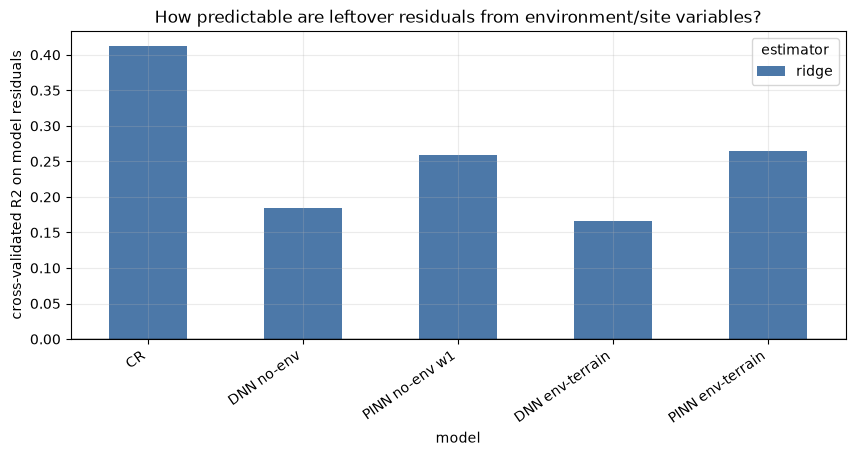

In [27]:
pivot_pred = predictability.pivot(index="model", columns="estimator", values="cv_r2").reindex(map_models)
pivot_pred.plot.bar(figsize=(10, 4), color=["#4c78a8", "#f58518"][:len(pivot_pred.columns)])
plt.axhline(0, color="black", linewidth=1)
plt.title("How predictable are leftover residuals from environment/site variables?")
plt.ylabel("cross-validated R2 on model residuals")
plt.xticks(rotation=35, ha="right")
pivot_pred

## Row-Level Residual Predictability (age-varying, not pooled per plot)

The residual-predictability check above uses `mean_residual`, one row per plot. That is conservative for spatial analysis, but it removes age/year variation. This optional section repeats the idea at row level, so it can ask whether environment/site variables explain individual-year errors.

This section is useful but slower, so it is opt-in by default. Set `RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY = True` in the next cell when you need it.

In [28]:
RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY = False

if RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY:
    # Row-level join -- same environmental/coordinate merge as plot_residuals above, but on
    # plot_df directly (one row per plot-survey-year), not the grouped-by-plot version.
    row_level_env = plot_df.merge(coords_unique, on=["identification", "cpmt"], how="left", suffixes=("", "_coord"))
    row_level_env = row_level_env.merge(env_unique[env_extra_cols], on=["identification", "cpmt"], how="left")
    # residual_predictability_for_model() expects a "mean_residual" column -- reusing the same
    # function as the pooled check above, not rewriting it; the name is a holdover from that
    # reuse, this is genuinely the row-level residual here, not a mean of anything.
    row_level_env = row_level_env.rename(columns={"residual": "mean_residual"})

    row_level_predictability_rows = []
    for model in map_models:
        for estimator_name in ["ridge", "rf"]:
            row_level_predictability_rows.append(
                residual_predictability_for_model(row_level_env, model, feature_cols, estimator_name)
            )
    row_level_predictability = pd.DataFrame(row_level_predictability_rows)
    row_level_pivot = row_level_predictability.pivot(index="model", columns="estimator", values="cv_r2").reindex(map_models)

    print("Pooled per-plot (mean_residual, averaged across years):")
    display(pivot_pred)
    print("Row-level (age-varying, one row per plot-survey-year):")
    display(row_level_pivot)
    print("Difference (row-level minus pooled), RF column -- positive means row-level finds MORE predictable structure:")
    (row_level_pivot["rf"] - pivot_pred["rf"]).round(4)
else:
    row_level_predictability = pd.DataFrame({
        "message": ["Row-level residual predictability skipped because RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY=False"]
    })
    row_delta_summary = pd.DataFrame()
    display(row_level_predictability)


,message
0,Row-level residual predictability skipped beca...


## Model-Failure Interpretation Table

This table is a structured summary of the current evidence for each hypothesis. Built from the live variables computed by the cells above in THIS run (`seed_delta_summary`, `concentration_summary`, `spatial_summary`, `pivot_pred`, `row_level_pivot`) -- not retyped prose. Re-executing this notebook regenerates every value in the table below from scratch, so it can't silently go stale the way a hardcoded version can.

In [29]:
def fmt_delta(row):
    return f"mean={row['mean_delta_r2']:+.4f}, SD={row['sd_delta_r2']:.4f}, n={int(row['n_seed_pairs'])}"

def optional_value(frame, row_label, col_label, default="not run in fast path"):
    try:
        return frame.loc[row_label, col_label]
    except Exception:
        return default

dnn_seed_row = seed_delta_summary[seed_delta_summary["comparison"] == "DNN env - no-env"].iloc[0]
pinn_seed_row = seed_delta_summary[seed_delta_summary["comparison"] == "PINN env - no-env"].iloc[0]

dnn_ci_excludes_zero = (dnn_seed_row["mean_delta_r2"] - 2.365 * dnn_seed_row["sd_delta_r2"] / np.sqrt(dnn_seed_row["n_seed_pairs"])) > 0
pinn_delta_is_tiny = abs(pinn_seed_row["mean_delta_r2"]) < 0.01

dnn_noenv_row = concentration_summary[concentration_summary["model"] == "DNN no-env"].iloc[0]
cr_row = concentration_summary[concentration_summary["model"] == "CR"].iloc[0]

if "morans_i" in spatial_summary.columns:
    morans_nonmissing = spatial_summary.dropna(subset=["morans_i"])
    morans_i_best_model = morans_nonmissing.sort_values("morans_i").iloc[0]["model"] if len(morans_nonmissing) else "not resolved"
    morans_i_cr = spatial_summary[spatial_summary["model"] == "CR"]["morans_i"].iloc[0] if "CR" in spatial_summary.get("model", pd.Series()).values else np.nan
    moran_evidence = f"Available in this run. CR Moran's I={morans_i_cr:.4f}; lowest residual Moran's I is {morans_i_best_model}."
    moran_status = "see spatial_summary"
else:
    moran_evidence = "Not evaluated in the fast path. Set RUN_GLOBAL_SPATIAL_AUTOCORR=True to run the full Moran's I comparison."
    moran_status = "not run in fast path"

pooled_dnn_env_rf = optional_value(pivot_pred, "DNN env-terrain", "rf")
pooled_dnn_noenv_rf = optional_value(pivot_pred, "DNN no-env", "rf")
try:
    row_dnn_env_rf = row_level_pivot.loc["DNN env-terrain", "rf"]
    row_dnn_noenv_rf = row_level_pivot.loc["DNN no-env", "rf"]
except Exception:
    row_dnn_env_rf = row_dnn_noenv_rf = "not run in fast path"

model_failure_interpretation = pd.DataFrame([
    {
        "hypothesis": "The whole modelling pipeline is broken",
        "current_evidence": f"Weak. DNN R2={extra_metrics.loc['DNN no-env','r2']:.3f} vs CR R2={extra_metrics.loc['CR','r2']:.3f} -- real improvement over the mechanistic baseline.",
        "status": "unlikely",
        "next_check": "Small-sample overfit check remains useful but the main pipeline is not obviously broken.",
    },
    {
        "hypothesis": "PINN(w=1) is better than DNN",
        "current_evidence": "Not supported. The DNN is stronger than PINN(w=1) in the primary spatial-block comparisons currently loaded.",
        "status": "not supported",
        "next_check": "Only revisit after a PINN-specific architecture/loss change.",
    },
    {
        "hypothesis": "Current environmental terrain features improve DNN spatial generalisation",
        "current_evidence": f"Supported across paired split seeds loaded here. Paired-seed delta: {fmt_delta(dnn_seed_row)}. 95% CI excludes zero: {dnn_ci_excludes_zero}.",
        "status": "supported for loaded paired seeds",
        "next_check": "Report mean +/- SD rather than seed 42 alone.",
    },
    {
        "hypothesis": "Current environmental terrain features improve PINN spatial generalisation",
        "current_evidence": f"Weak/near-zero in available paired seeds. Paired-seed delta: {fmt_delta(pinn_seed_row)}.",
        "status": "weak / near-zero",
        "next_check": "Mechanism change likely matters more than simply adding terrain to the current PINN.",
    },
    {
        "hypothesis": "Errors are diffuse, irreducible noise",
        "current_evidence": f"Rejected as the main story. DNN no-env worst-100 rows: {dnn_noenv_row['top3_compartment_worst_rows']:.0f}/100 from top-3 compartments, {dnn_noenv_row['repeat_offender_plots']:.0f} repeat-offender plots. CR is also concentrated: {cr_row['top3_compartment_worst_rows']:.0f}/100 from top-3 compartments.",
        "status": "not the main story",
        "next_check": "Inspect top compartments/repeat plots for disturbance, boundary, species-definition, or survey-provenance issues.",
    },
    {
        "hypothesis": "A few problematic compartments/plots drive many bad predictions",
        "current_evidence": "Supported by concentration_summary and the problem-compartment maps.",
        "status": "supported",
        "next_check": "Use the map sections above to inspect where these clusters sit in the forest.",
    },
    {
        "hypothesis": "Residual spatial autocorrelation is lower in newer models than CR",
        "current_evidence": moran_evidence,
        "status": moran_status,
        "next_check": "Turn on RUN_GLOBAL_SPATIAL_AUTOCORR for the full statistical test.",
    },
    {
        "hypothesis": "Adding terrain features leaves less residual predictability from environment/site variables",
        "current_evidence": f"Fast path reports ridge only. RF pooled values: DNN env={pooled_dnn_env_rf}, DNN no-env={pooled_dnn_noenv_rf}; row-level RF values: DNN env={row_dnn_env_rf}, DNN no-env={row_dnn_noenv_rf}.",
        "status": "depends on optional RF/row-level diagnostics",
        "next_check": "Set RUN_RESIDUAL_RF=True and RUN_ROW_LEVEL_RESIDUAL_PREDICTABILITY=True for the slower nonlinear check.",
    },
])
model_failure_interpretation

,hypothesis,current_evidence,status,next_check
0,The whole modelling pipeline is broken,Weak. DNN R2=0.633 vs CR R2=0.405 -- real impr...,unlikely,Small-sample overfit check remains useful but ...
1,PINN(w=1) is better than DNN,Not supported. The DNN is stronger than PINN(w...,not supported,Only revisit after a PINN-specific architectur...
2,Current environmental terrain features improve...,Supported across paired split seeds loaded her...,supported for loaded paired seeds,Report mean +/- SD rather than seed 42 alone.
3,Current environmental terrain features improve...,Weak/near-zero in available paired seeds. Pair...,weak / near-zero,Mechanism change likely matters more than simp...
4,"Errors are diffuse, irreducible noise",Rejected as the main story. DNN no-env worst-1...,not the main story,Inspect top compartments/repeat plots for dist...
5,A few problematic compartments/plots drive man...,Supported by concentration_summary and the pro...,supported,Use the map sections above to inspect where th...
6,Residual spatial autocorrelation is lower in n...,Not evaluated in the fast path. Set RUN_GLOBAL...,not run in fast path,Turn on RUN_GLOBAL_SPATIAL_AUTOCORR for the fu...
7,Adding terrain features leaves less residual p...,Fast path reports ridge only. RF pooled values...,depends on optional RF/row-level diagnostics,Set RUN_RESIDUAL_RF=True and RUN_ROW_LEVEL_RES...


## Reading The Results

Use this checklist when interpreting the notebook:

1. Does RMSE improve relative to Chapman-Richards?
2. Does the residual distribution narrow and centre near zero?
3. Do age/year bias curves flatten?
4. Do compartment biases shrink?
5. Does spatial autocorrelation fall relative to CR residuals?
6. Are the leftover residuals less predictable from environmental/site variables?

A model that improves RMSE but leaves the same spatial/environmental residual signal has improved prediction but has not explained the process found by the statistical residual analysis. A model that reduces Moran's I or residual predictability has stronger evidence that it captured the structured residual process.

## Note: Regression/Residual Kriging (proposed, not yet built)

Before re-proposing a spatial-lag-style feature to recover the compartment-clustered structure shown above: a plain fixed-radius version was already tried and found structurally incompatible with `spatial_block_split` (see `documentation/experiment_log.md`'s 2026-08-02 entry -- 96%+ of held-out plots have zero legitimate same-split neighbours within 75m, since compartments are large contiguous units). Regression/residual kriging (a variogram-based method, not a hard radius cutoff) is a real, checkable alternative with precedent in canopy height mapping specifically -- proposed in the same log entry, not yet implemented. Any future spatial-lag attempt should start from a variogram-based method, not another fixed-radius feature.